# 02 · Classical statistical analysis of the experiment

Before any model: is there a treatment effect on visits and conversions, how large, and how certain? Then: does
randomization actually hold in this pooled benchmark? Full-data results come from `uv run causalml stats --mode full`.

In [1]:
import json
import numpy as np
import pandas as pd
from IPython.display import Image, display

from src.utils import REPO_ROOT

FIG, TAB, MET = (REPO_ROOT / "results" / d for d in ("figures", "tables", "metrics"))
pd.set_option("display.float_format", lambda v: f"{v:,.4g}")
pd.set_option("display.max_colwidth", 120)

def fig(name, width=950):
    display(Image(filename=str(FIG / f"{name}.png"), width=width))

def table(name):
    return pd.read_csv(TAB / f"{name}.csv")

def metrics(name):
    return json.loads((MET / f"{name}.json").read_text())

## Two-proportion tests

For each outcome, H0: p_treated = p_control against H1: p_treated ≠ p_control, pooled-SE z-test; unpooled Wald CI
for the difference; delta-method CI on the log risk ratio for the relative lift. The same function on the
development sample:

In [2]:
from src.causal.ate import two_proportion_inference
from src.data.load import load_criteo

dev = load_criteo("dev", columns=["treatment", "visit", "conversion"])
for y in ["visit", "conversion"]:
    g = dev.groupby("treatment")[y].agg(["sum", "count"])
    r = two_proportion_inference(int(g.loc[1, "sum"]), int(g.loc[1, "count"]), int(g.loc[0, "sum"]), int(g.loc[0, "count"]))
    print(f"{y:10s} effect {r['absolute_effect']['estimate']:+.5f}  95% CI {np.round(r['absolute_effect']['ci95_wald'], 5)}  "
          f"z = {r['z_test']['statistic']:.2f}  p = {r['z_test']['p_value']:.2g}  relative lift {r['relative_lift']['estimate']:+.1%}")

visit      effect +0.01034  95% CI [0.00906 0.01163]  z = 14.59  p = 3.2e-48  relative lift +27.1%
conversion effect +0.00114  95% CI [0.00084 0.00144]  z = 6.33  p = 2.5e-10  relative lift +58.7%


## Full data: hypotheses, statistics, p-values, CIs, interpretation

In [3]:
stats = metrics("stats")
rows = []
for outcome, r in stats["outcomes"].items():
    h = r["hypothesis_test"]
    rows.append({"outcome": outcome, "null": h["null"], "alternative": h["alternative"], "test": h["test"],
                 "statistic": h["statistic"], "p_value": h["p_value"], "log10_p": h["log10_p_value"], "ci95": h["ci95"],
                 "bootstrap_ci95": r["bootstrap"]["absolute"]["ci95_percentile"]})
display(pd.DataFrame(rows))
for outcome, r in stats["outcomes"].items():
    print(f"{outcome}: {r['hypothesis_test']['interpretation']}")

,outcome,null,alternative,test,statistic,p_value,log10_p,ci95,bootstrap_ci95
0,visit,H0: p_T = p_C (assignment does not change the visit rate),H1: p_T != p_C (two-sided),two-proportion z-test with pooled SE,65.25,0,-926.4,"[0.010055628213713731, 0.010629178044682837]","[0.010060163777446389, 0.010622779770390748]"
1,conversion,H0: p_T = p_C (assignment does not change the conversion rate),H1: p_T != p_C (two-sided),two-proportion z-test with pooled SE,28.52,7.308e-179,-178.1,"[0.0010845057902364738, 0.001219240314026782]","[0.001083396454219061, 0.0012215264528168943]"
2,exposure,H0: p_T = p_C (assignment does not change the exposure rate),H1: p_T != p_C (two-sided),two-proportion z-test with pooled SE,279.2,0,-1.693e+04,"[0.035930754717800543, 0.03614270024659925]","[0.03593245575168176, 0.03614294953442644]"


visit: In this benchmark sample the visit rate was 4.8543% in the ad-eligible (treatment) arm vs 3.8201% in control, a difference of +1.0342 percentage points (95% CI 1.0056 to 1.0629), a 27.1% relative lift; the z-test rejects H0: p_T = p_C (z = 65.2, p < 1e-300 (log10 p = -926)). Read causally this is the effect of assignment, which relies on randomization (see randomization.finding).
conversion: In this benchmark sample the conversion rate was 0.3089% in the ad-eligible (treatment) arm vs 0.1938% in control, a difference of +0.1152 percentage points (95% CI 0.1085 to 0.1219), a 59.4% relative lift; the z-test rejects H0: p_T = p_C (z = 28.5, p = 7.31e-179). Read causally this is the effect of assignment, which relies on randomization (see randomization.finding).
exposure: In this benchmark sample the exposure rate was 3.6037% in the ad-eligible (treatment) arm vs 0.0000% in control, a difference of +3.6037 percentage points (95% CI 3.5931 to 3.6143) (relative lift undefined: the con

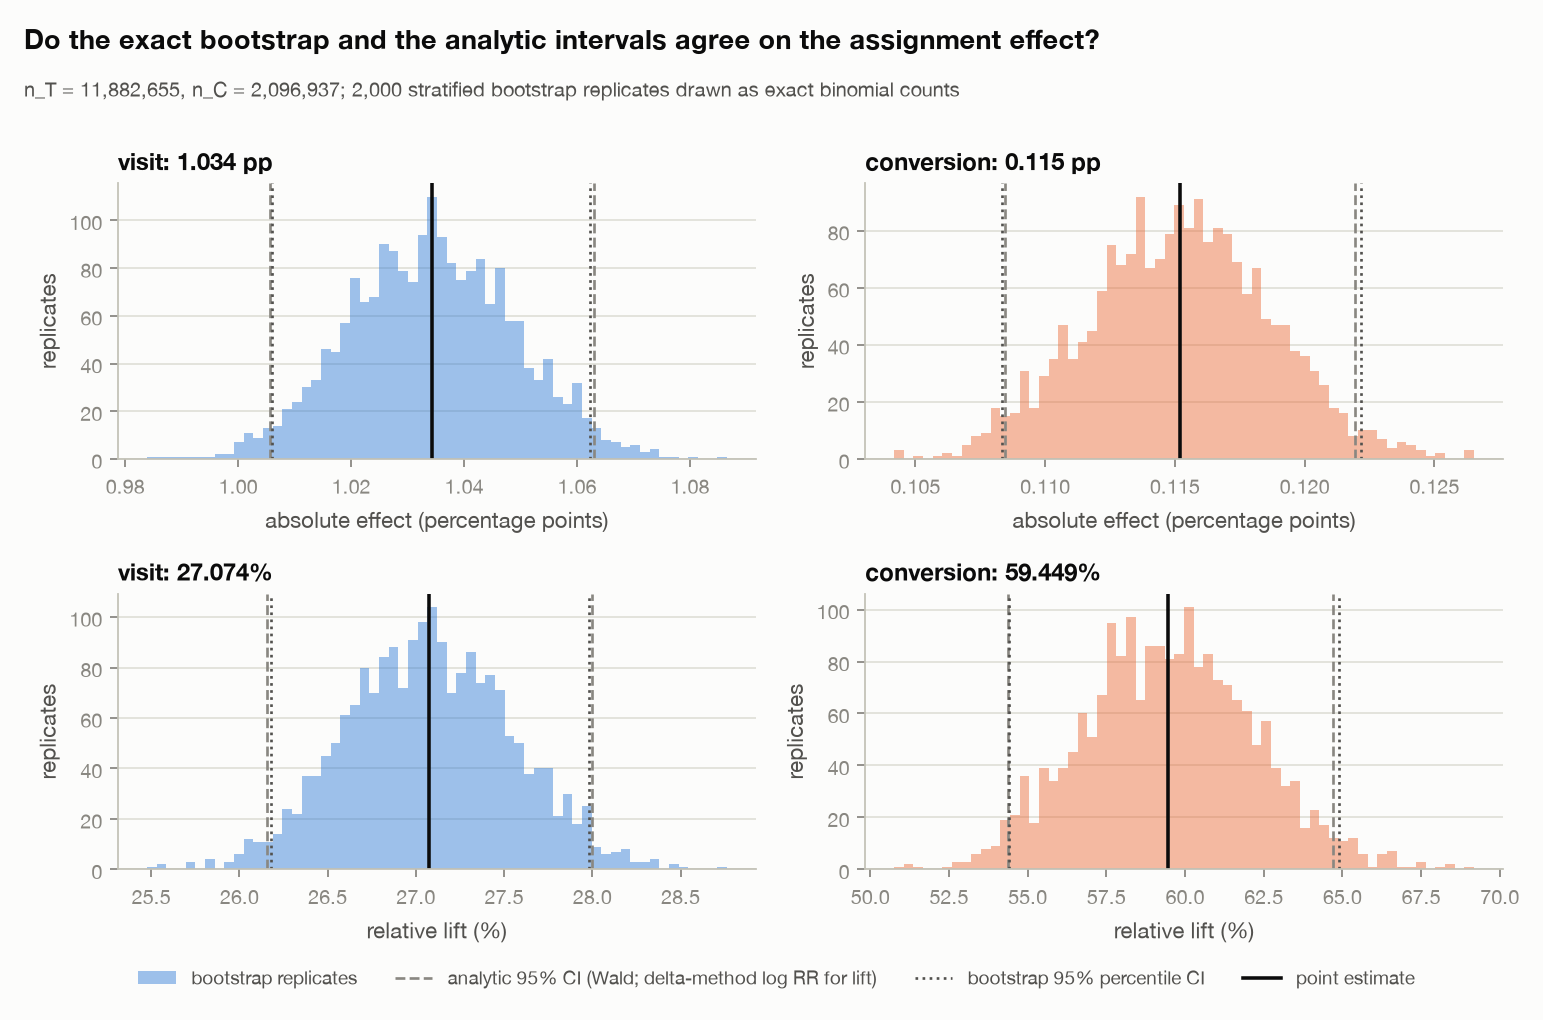

,outcome,rate_treatment,rate_control,absolute_effect,wald_lo,wald_hi,newcombe_lo,newcombe_hi,boot_lo,boot_hi,relative_lift,rel_delta_lo,rel_delta_hi,rel_boot_lo,rel_boot_hi,z,log10_p,mde_full,mde_test_split
0,visit,0.04854,0.0382,0.01034,0.01006,0.01063,0.01005,0.01063,0.01006,0.01062,0.2707,0.2616,0.28,0.2618,0.2798,65.25,-926.4,0.0004035,0.0009059
1,conversion,0.003089,0.001938,0.001152,0.001085,0.001219,0.001084,0.001219,0.001083,0.001222,0.5945,0.5437,0.6469,0.5441,0.6489,28.52,-178.1,9.369e-05,0.0002134
2,exposure,0.03604,0,0.03604,0.03593,0.03614,0.03593,0.03614,0.03593,0.03614,NaN,NaN,NaN,NaN,NaN,279.2,-1.693e+04,2.552e-06,1.276e-05


In [4]:
fig("stats_effects"); table("stats_effects")

The bootstrap uses the exact equivalence between a stratified row bootstrap of a binary outcome and drawing each
arm's positive count from Binomial(n_arm, p̂_arm), so 2,000 replicates over 14M rows cost nothing.

## Randomization checks

Randomization is what makes the difference in means an unbiased ATE: if T is independent of (Y(0), Y(1)),
E[Y | T=1] − E[Y | T=0] = E[Y(1) − Y(0)]. Balance checks can refute that assumption but never prove it.

In [5]:
rand = stats["randomization"]
print(json.dumps({k: v for k, v in rand.items() if not isinstance(v, (list,))}, indent=1, default=str)[:3000])

{
 "identification": "By design, treatment is randomized assignment (ad eligibility), so T is independent of the potential outcomes (Y(0), Y(1)) and of X. Then E[Y|T=1] = E[Y(1)|T=1] = E[Y(1)] and E[Y|T=0] = E[Y(0)], and the difference in means E[Y|T=1] - E[Y|T=0] is an unbiased estimate of the ATE of assignment (the intention-to-treat effect) with no model of Y. SUTVA (no interference between users, one version of treatment) is also required. If randomization holds, covariates are not needed for identification and regression, IPW and AIPW only change the variance; if T depends on X in the sample (see the randomization checks), the difference in means can be biased and adjustment for X (under ignorability given X) becomes necessary rather than optional.",
 "what_balance_checks_can_show": "Balance checks can detect a failed or leaky randomization: a treated share different from the design, features that predict assignment (as in v1 of this dataset, where the test id leaked into features

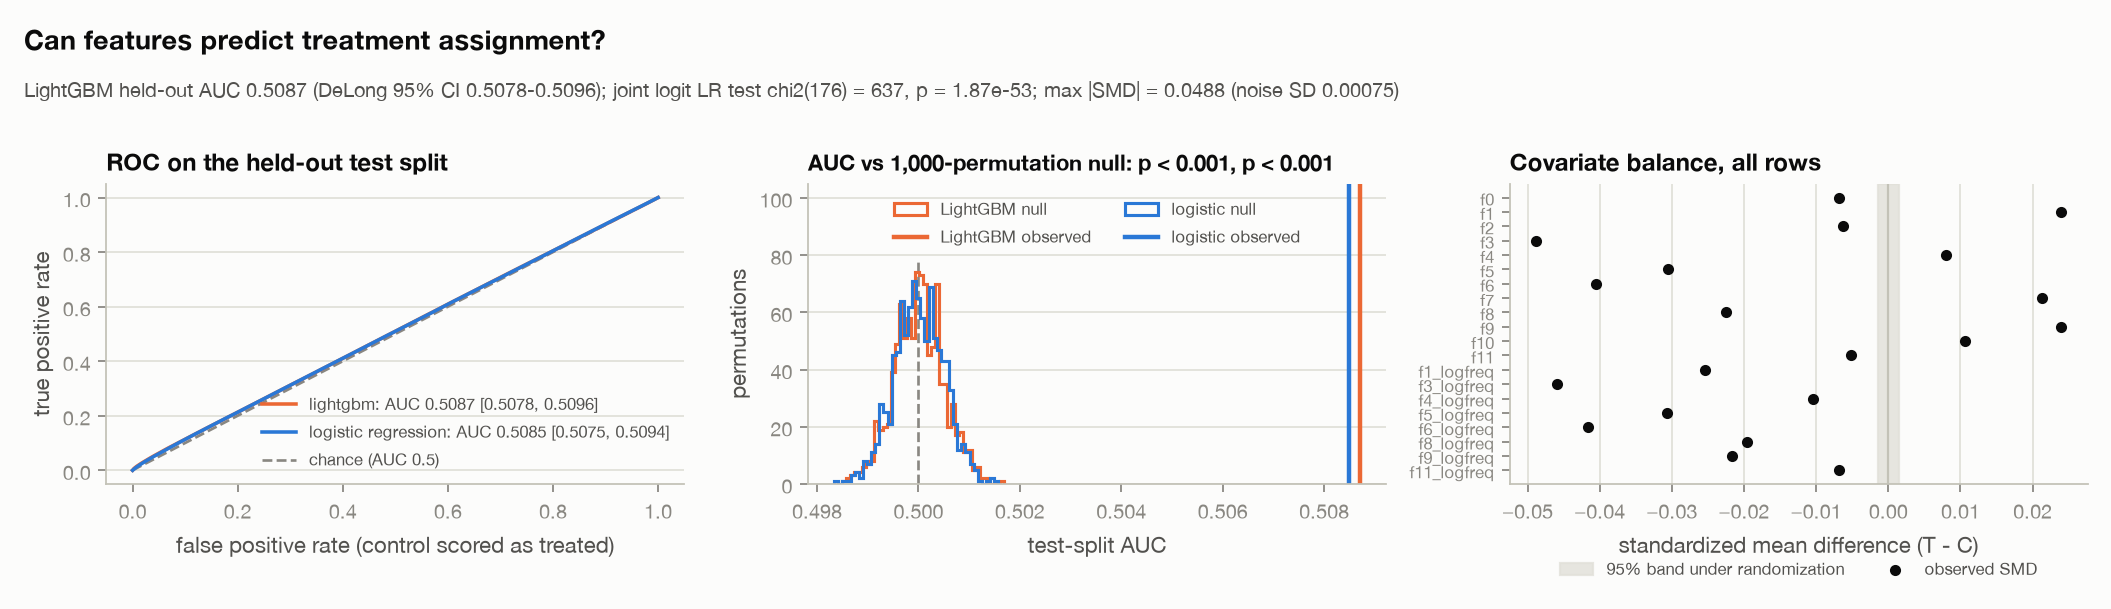

In [6]:
fig("stats_balance")

A classifier two-sample test (can a model predict treatment from the features better than chance on held-out data?)
and a joint likelihood-ratio test both reject independence of T and X. The paper's original C2ST used far fewer rows.
The practical consequence, quantified in notebook 04: the adjusted ATE is materially smaller than the raw difference.